# Chapter 2: The challenge of time series

In [1]:
import pandas as pd
from pathlib import Path

In [2]:
dir = Path.cwd().parent

In [3]:
df = pd.read_csv(dir / "data" / "bugatti_sales.csv")
print(df.head(n=5))

   year month  sales
0  2016   Mar      1
1  2016   Apr      2
2  2016   Sep      2
3  2016   Nov      1
4  2016   Dec      1


We can see from the table that several months are missing (no data) between particular dates.

In [4]:
# Convert year value to a string and then combine with month
df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'],
format='%Y-%b')

# Set new month variable to index and resample to get missing dates, filled with 0
df = df.set_index('date').resample('ME').sum().fillna(0)

# Drop used columns
df = df.drop(['year', 'month'], axis=1)

# Reset index
df = df.reset_index()
print(df.head(n=5))

        date  sales
0 2016-03-31      1
1 2016-04-30      2
2 2016-05-31      0
3 2016-06-30      0
4 2016-07-31      0


You can see in the resampled data that we have added several dates that now have 0 sales. We could also resample to a higher resolution, such as quarterly, depending on business requirements. This would smooth out the sales over time, but could be less informative.

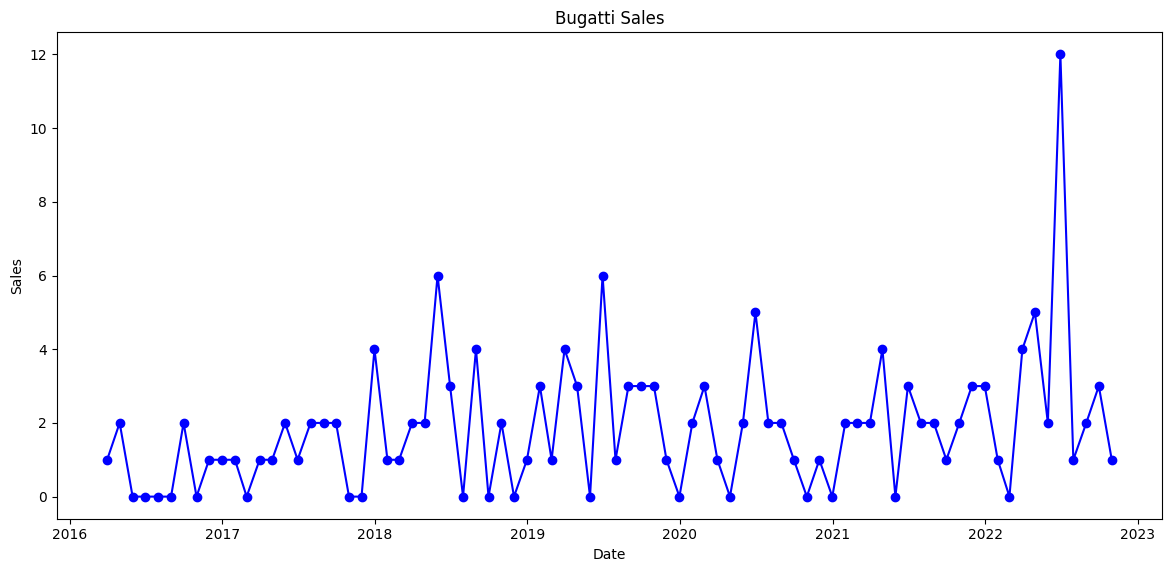

In [5]:
from Utilities.Charting import plot_timeseries
plot, _, _ = plot_timeseries(df, 'date', 'sales', 'Bugatti Sales',  marker='o')

In [6]:
dir = Path.cwd().parent / "Data" / "M5_t20_ABC.csv"
panel_df = pd.read_csv(dir)
panel_df.head(n=5)

,Unnamed: 0,id,item_id,dept_id,cat_id,state_id,sold,date,sell_price,count,ABC_class
0,809259,FOODS_2_197_CA_3_evaluation,FOODS_2_197,FOODS_2,FOODS,CA,39,2011-01-29,2.98,1969,A
1,809260,FOODS_2_197_CA_3_evaluation,FOODS_2_197,FOODS_2,FOODS,CA,65,2011-01-30,2.98,1969,A
2,809261,FOODS_2_197_CA_3_evaluation,FOODS_2_197,FOODS_2,FOODS,CA,32,2011-01-31,2.98,1969,A
3,809262,FOODS_2_197_CA_3_evaluation,FOODS_2_197,FOODS_2,FOODS,CA,44,2011-02-01,2.98,1969,A
4,809263,FOODS_2_197_CA_3_evaluation,FOODS_2_197,FOODS_2,FOODS,CA,46,2011-02-02,2.98,1969,A


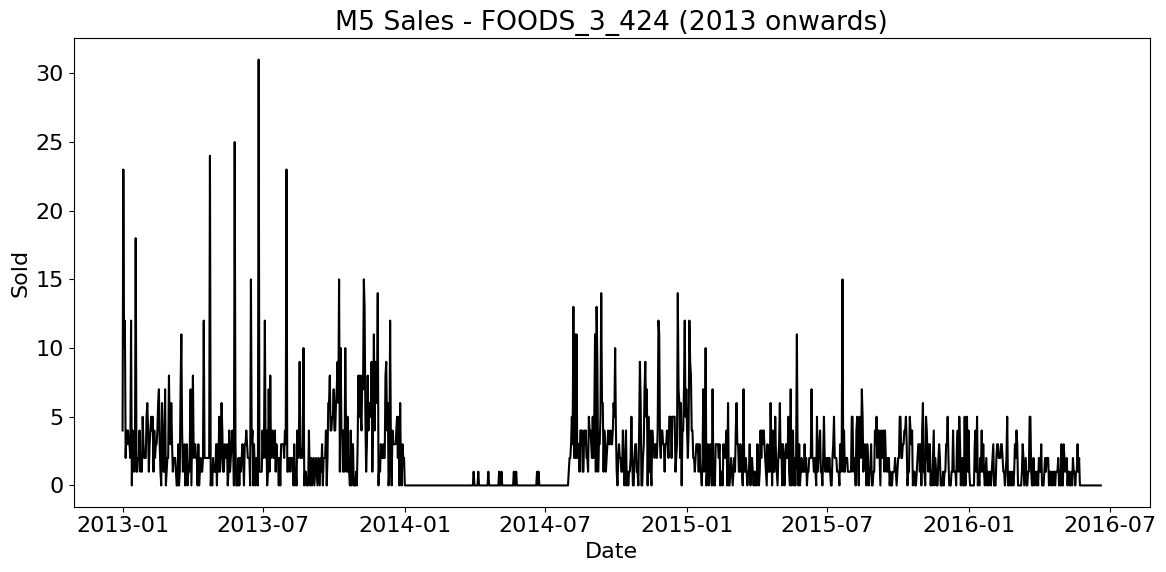

In [7]:
series_df = panel_df.loc[panel_df.item_id == 'FOODS_3_424'].copy()
series_df['date'] = pd.to_datetime(series_df['date'])
# let's make this 2013 onwards
series_df = series_df[series_df['date'].dt.year >= 2013].copy()

plot, _, _ = plot_timeseries(series_df, 'date', 'sold', 'M5 Sales - FOODS_3_424 (2013 onwards)', color='black')

### Data Imputation:

In [8]:
# Define the gap period
gap_start = '2014-01-01'
gap_end = '2014-08-01'

# Boolean to identify gap
gap_mask = (series_df['date'] >= gap_start) & (series_df['date'] < gap_end)

gap_mask

93246    False
93247    False
93248    False
93249    False
93250    False
         ...  
94507    False
94508    False
94509    False
94510    False
94511    False
Name: date, Length: 1266, dtype: bool

In [9]:
# create dataframe to hold imputed data
df_imputed = series_df.copy()
df_imputed['mean_imputed'] = series_df['sold'].replace(0, df_imputed['sold'].mean())

In [10]:
from matplotlib import pyplot as plt

def plot_imputed_sales(df: pd.DataFrame, y_variable : str, title_suffix: str=""):
    plot, _, ax = plot_timeseries(df, 'date', y_variable,
                          title='M5 Sales - FOODS_3_424 (2013 onwards)-'+title_suffix, color='black', show=False)
    # Highlight the imputed region
    gap_start = '2014-01-01'
    gap_end = '2014-08-01'
    ax.axvspan(gap_start, gap_end, color='#b512b8', alpha=0.3)
    plot.show()

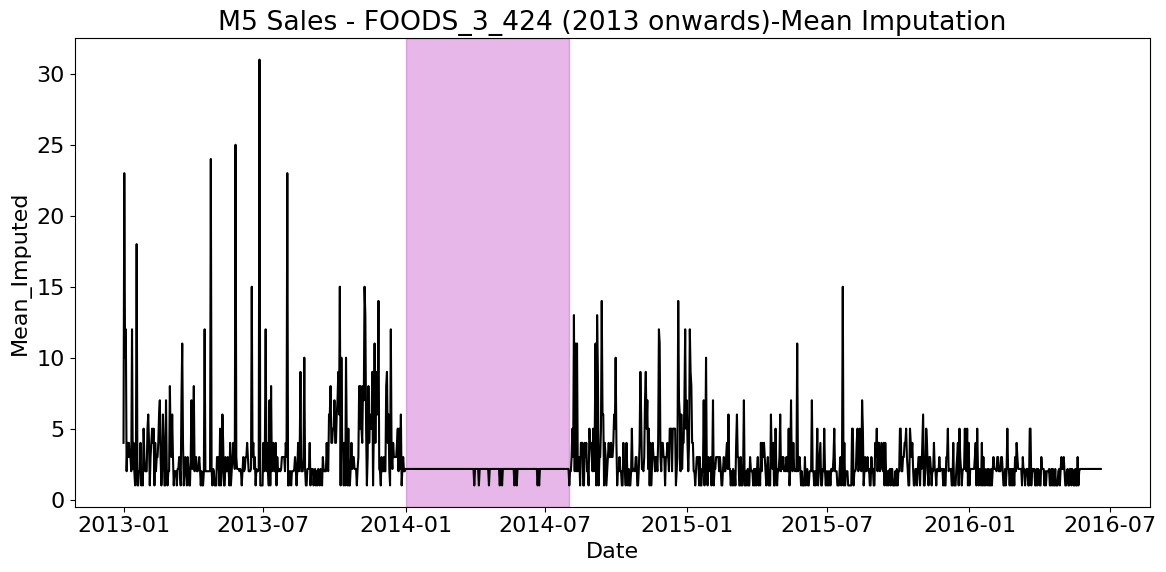

In [11]:
plot_imputed_sales(df_imputed, "mean_imputed", "Mean Imputation")

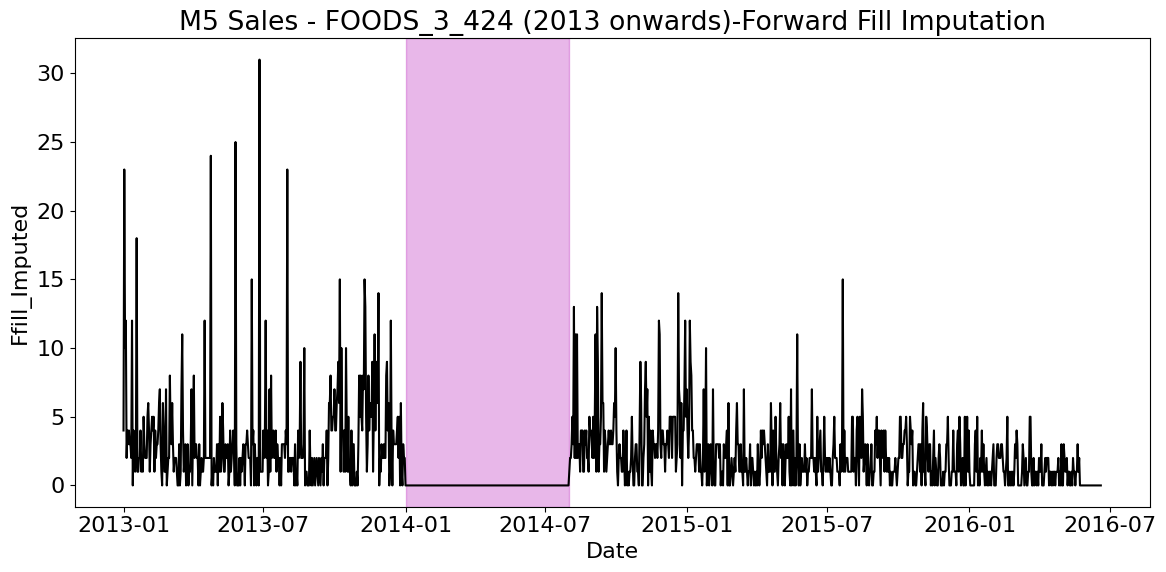

In [12]:
df_imputed['ffill_imputed'] = df_imputed['sold'].copy()
df_imputed.loc[gap_mask, 'ffill_imputed'] = df_imputed.loc[~gap_mask, 'sold'].iloc[-1]
plot_imputed_sales(df_imputed, "ffill_imputed", "Forward Fill Imputation")

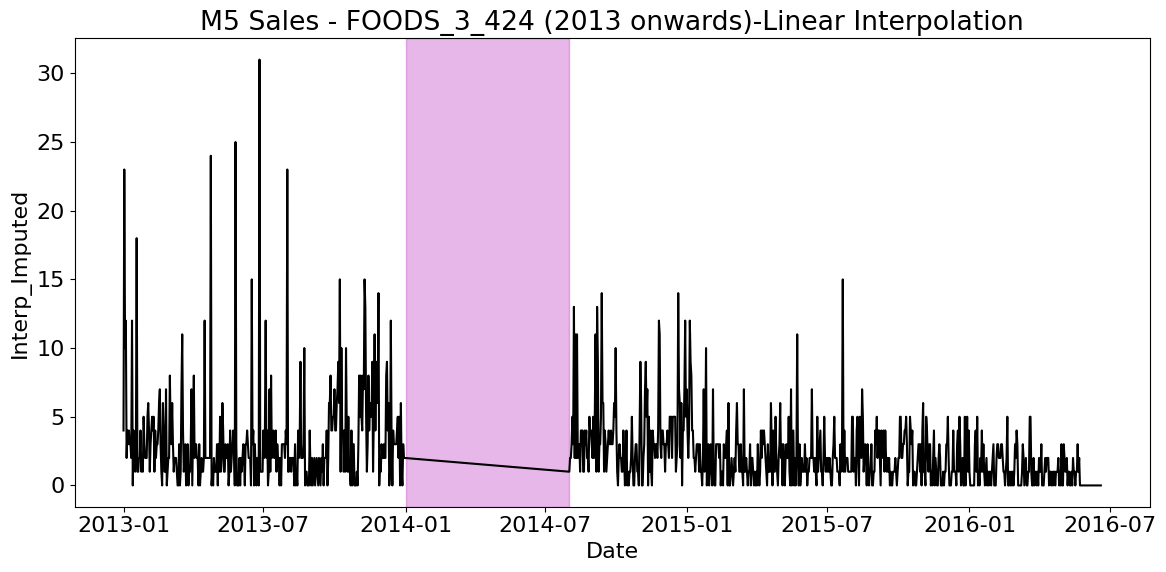

In [13]:
import numpy as np

df_imputed['interp_imputed'] = df_imputed['sold'].copy()
df_imputed.loc[gap_mask, 'interp_imputed'] = np.nan
df_imputed['interp_imputed'] = df_imputed['interp_imputed'].interpolate()
plot_imputed_sales(df_imputed, "interp_imputed", "Linear Interpolation")

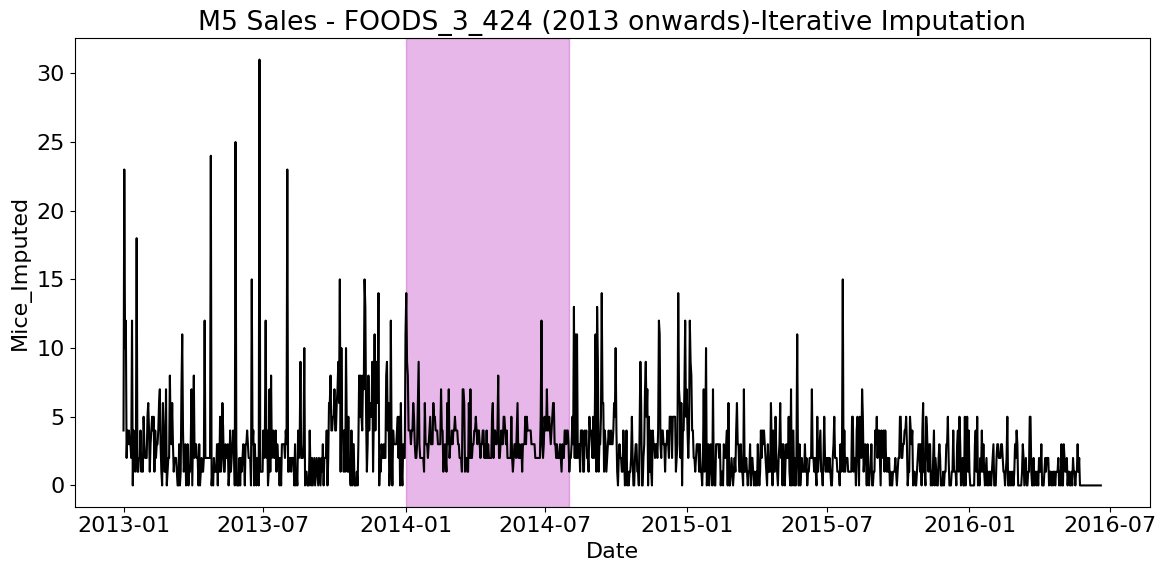

In [14]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from Utilities.DataFrameUtilities import dataframe_date_enrichment

dataframe_date_enrichment(df_imputed)

# Instantiate imputer
mice_imputer = IterativeImputer(
 estimator=RandomForestRegressor(n_estimators=300),
 max_iter=12, random_state=3962)

# Prepare data for imputation
columns_for_imputation = ['sold', 'year', 'month', 'day',
 'dayofweek', 'is_weekend']
df_mice_impute = df_imputed[columns_for_imputation].copy()
df_mice_impute.loc[gap_mask, 'sold'] = np.nan

# Run imputation
imputed_data = mice_imputer.fit_transform(df_mice_impute)

# Update df_imputed dataframe with MICE imputed values
df_imputed['mice_imputed'] = df_imputed['sold'].copy()
df_imputed.loc[gap_mask, 'mice_imputed'] = imputed_data[
 gap_mask, 0].astype(df_imputed['sold'].dtype)

# Plot
plot_imputed_sales(df_imputed, "mice_imputed", "Iterative Imputation")

Patterns in time
The first step in understanding the patterns and variations of time-series data (or stochastic processes if you will) is conducting EDA: checking data ranges, looking for missing data, calculating basic
statistics, and so on

In [15]:
# Check date-range
print(f"Date Range: {df_imputed['date'].min()} to {df_imputed['date'].max()}")
print(f"Number of Observations: {len(df_imputed)}")

# Check for any gaps in date sequence
df_imputed['date_diff'] = df_imputed['date'].diff()
gaps = df_imputed[df_imputed['date_diff'] > pd.Timedelta(days=1)]
if not gaps.empty:
    print(f"Number of gaps: {len(gaps)}")
else:
    print("No gaps found.")

# Check for missing values in time series
missing = df_imputed.isnull().sum()
if missing.any():
    print(missing[missing > 0])
else:
    print("No missing values found.")

# Basic descriptive statistics of numerical columns
print(df_imputed.describe())

Date Range: 2013-01-01 00:00:00 to 2016-06-19 00:00:00
Number of Observations: 1266
No gaps found.
date_diff    1
dtype: int64
         Unnamed: 0         sold                 date   sell_price   count  \
count  1.266000e+03  1266.000000                 1266  1266.000000  1266.0   
mean   2.041220e+06     2.161137  2014-09-25 12:00:00     3.842180  1969.0   
min    2.040587e+06     0.000000  2013-01-01 00:00:00     3.500000  1969.0   
25%    2.040903e+06     0.000000  2013-11-13 06:00:00     3.880000  1969.0   
50%    2.041220e+06     1.000000  2014-09-25 12:00:00     3.880000  1969.0   
75%    2.041536e+06     3.000000  2015-08-07 18:00:00     3.880000  1969.0   
max    2.041852e+06    31.000000  2016-06-19 00:00:00     3.880000  1969.0   
std    3.656070e+02     2.925035                  NaN     0.113804     0.0   

       mean_imputed  ffill_imputed  interp_imputed         year        month  \
count   1266.000000    1266.000000     1266.000000  1266.000000  1266.000000   
mean      

Decompostion:

Additive Decomposition:

In [16]:
from Utilities.ColorUtilities import custom_palette

In [17]:
df_imputed.head(n=20)

,Unnamed: 0,id,item_id,dept_id,cat_id,state_id,sold,date,sell_price,count,...,interp_imputed,year,month,monthname,day,dayofweek,dayofweekname,is_weekend,mice_imputed,date_diff
93246,2040587,FOODS_3_424_CA_3_evaluation,FOODS_3_424,FOODS_3,FOODS,CA,4,2013-01-01,3.88,1969,...,4.0,2013,1,January,1,1,Tuesday,0,4,NaT
93247,2040588,FOODS_3_424_CA_3_evaluation,FOODS_3_424,FOODS_3,FOODS,CA,23,2013-01-02,3.88,1969,...,23.0,2013,1,January,2,2,Wednesday,0,23,1 days
93248,2040589,FOODS_3_424_CA_3_evaluation,FOODS_3_424,FOODS_3,FOODS,CA,10,2013-01-03,3.88,1969,...,10.0,2013,1,January,3,3,Thursday,0,10,1 days
93249,2040590,FOODS_3_424_CA_3_evaluation,FOODS_3_424,FOODS_3,FOODS,CA,12,2013-01-04,3.88,1969,...,12.0,2013,1,January,4,4,Friday,0,12,1 days
93250,2040591,FOODS_3_424_CA_3_evaluation,FOODS_3_424,FOODS_3,FOODS,CA,2,2013-01-05,3.88,1969,...,2.0,2013,1,January,5,5,Saturday,1,2,1 days
93251,2040592,FOODS_3_424_CA_3_evaluation,FOODS_3_424,FOODS_3,FOODS,CA,4,2013-01-06,3.88,1969,...,4.0,2013,1,January,6,6,Sunday,1,4,1 days
93252,2040593,FOODS_3_424_CA_3_evaluation,FOODS_3_424,FOODS_3,FOODS,CA,3,2013-01-07,3.88,1969,...,3.0,2013,1,January,7,0,Monday,0,3,1 days
93253,2040594,FOODS_3_424_CA_3_evaluation,FOODS_3_424,FOODS_3,FOODS,CA,4,2013-01-08,3.88,1969,...,4.0,2013,1,January,8,1,Tuesday,0,4,1 days
93254,2040595,FOODS_3_424_CA_3_evaluation,FOODS_3_424,FOODS_3,FOODS,CA,3,2013-01-09,3.88,1969,...,3.0,2013,1,January,9,2,Wednesday,0,3,1 days
93255,2040596,FOODS_3_424_CA_3_evaluation,FOODS_3_424,FOODS_3,FOODS,CA,3,2013-01-10,3.88,1969,...,3.0,2013,1,January,10,3,Thursday,0,3,1 days


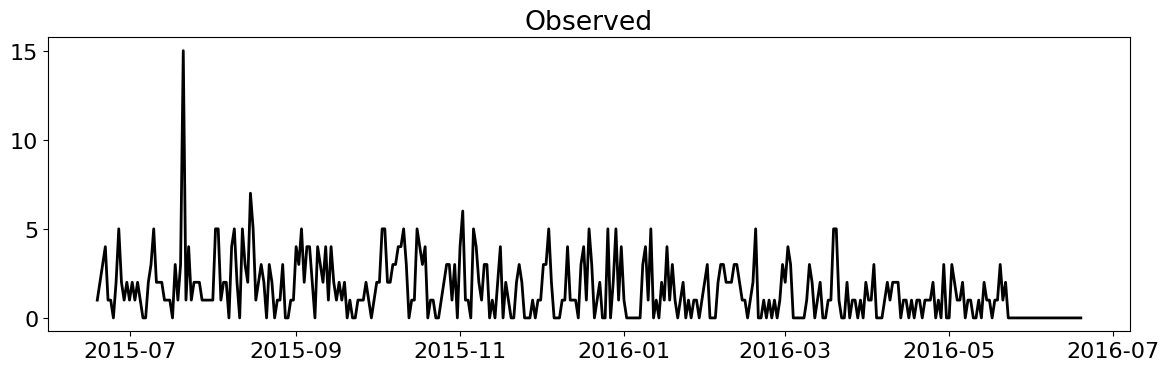

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm
from Utilities.DataFrameUtilities import dataframe_set_index

# Set date to index.
dataframe_set_index(df_imputed, 'date')

# sliced data to aid visualisation of seasonal patterns (e.g., last year of data)
end_date = df_imputed.index[-1]
start_date = end_date - pd.DateOffset(years=1)
df_sliced = df_imputed.loc[start_date:end_date]
# from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = sm.tsa.seasonal_decompose(df_sliced['mice_imputed'],period =28,
model='additive')

# Plotting function
def plot_component(data, title, color, plot_type='line'):
    plt.figure(figsize=(12, 4))
    if plot_type == 'line':
        plt.plot(data, color=color, linewidth=2)
    elif plot_type == 'scatter':
        plt.scatter(data.index, data, color=color, s=5)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Plot observed time series
plot_component(decomposition.observed, 'Observed', custom_palette[0])

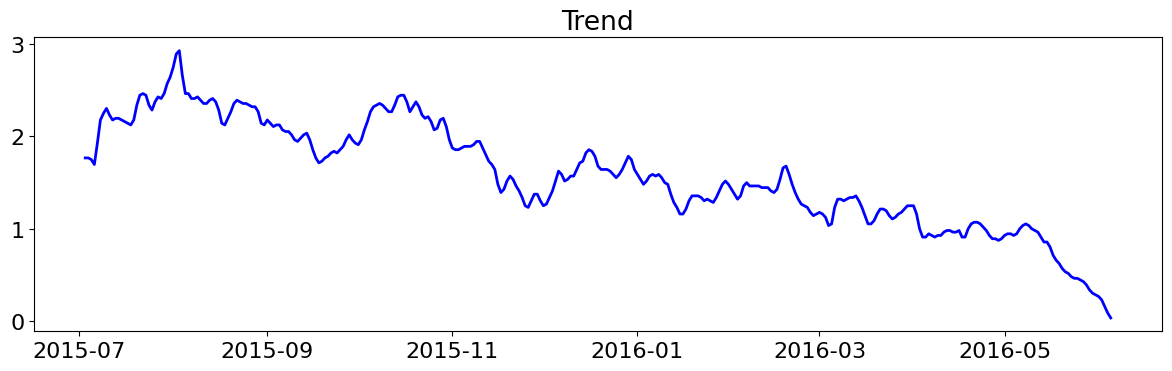

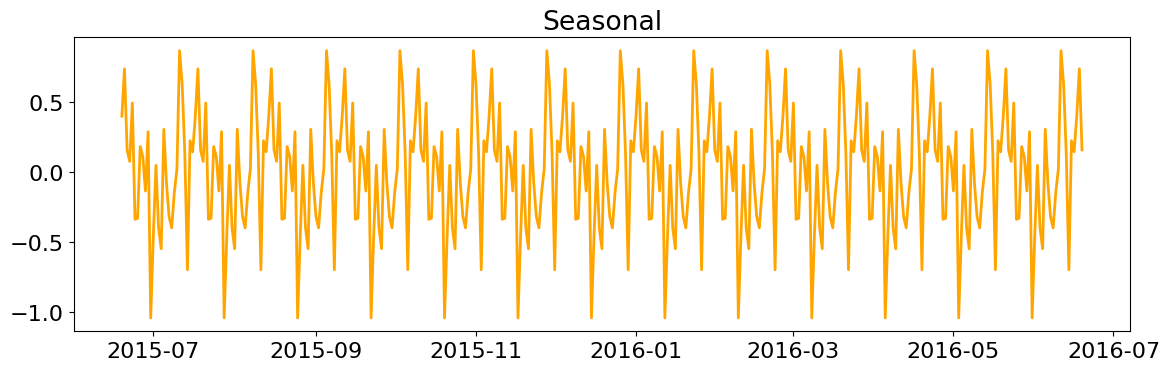

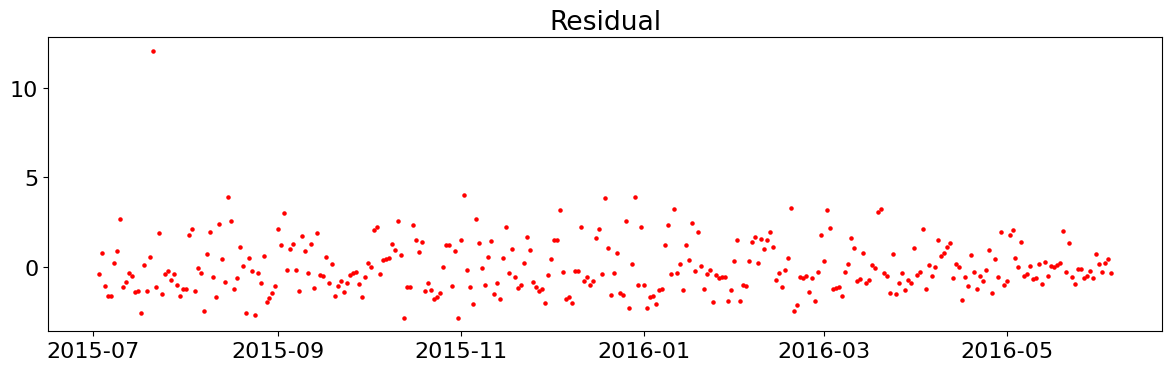

In [19]:
plot_component(decomposition.trend, 'Trend', custom_palette[1])
plot_component(decomposition.seasonal, 'Seasonal', custom_palette[2])
plot_component(decomposition.resid, 'Residual',custom_palette[3], plot_type='scatter')

C:\Users\brend\Desktop\PythonVenv\py3_13\Lib\site-packages\statsmodels\tsa\filters\hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


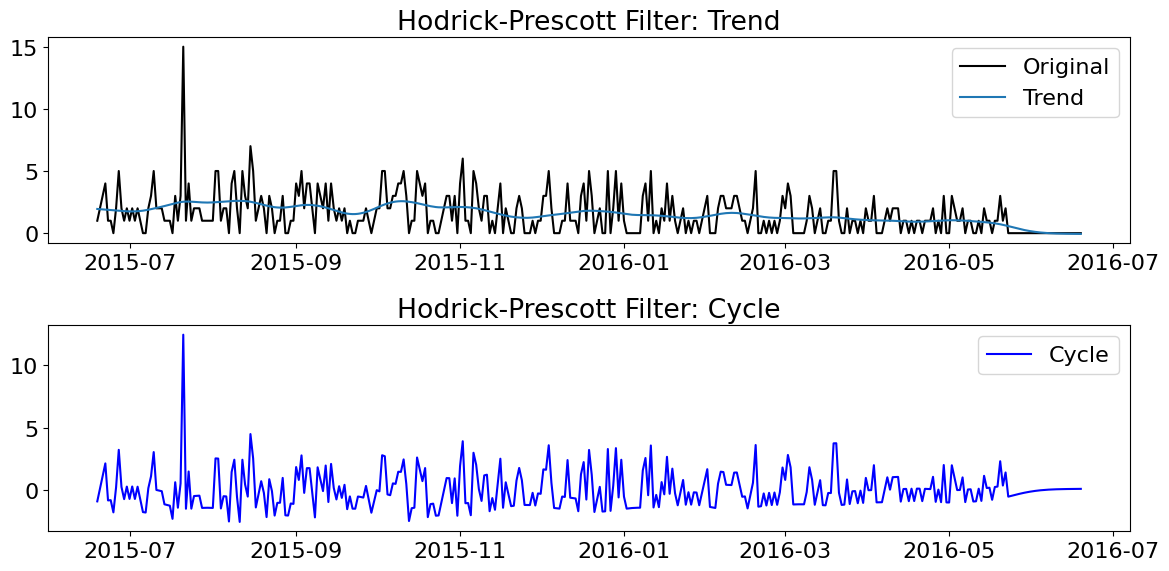

In [20]:
from statsmodels.tsa.filters.hp_filter import hpfilter
# Apply HP Filter
cycle, trend = hpfilter(df_sliced['mice_imputed'], lamb=1600)
# Plot
plt.figure(figsize=(12, 6))
plt.subplot(211)
plt.plot(df_sliced['mice_imputed'], label='Original', color = custom_palette[0])
plt.plot(trend, label='Trend')
plt.legend()
plt.title('Hodrick-Prescott Filter: Trend')
plt.subplot(212)
plt.plot(cycle, label='Cycle',color = custom_palette[1])
plt.legend()
plt.title('Hodrick-Prescott Filter: Cycle')
plt.tight_layout()
plt.show()

### Seasonaility plotting:

In [21]:
from Utilities.DataFrameUtilities import dataframe_date_enrichment
series_df = panel_df.loc[panel_df.item_id == 'FOODS_3_714'].copy()
dataframe_date_enrichment(series_df)
series_df

,Unnamed: 0,id,item_id,dept_id,cat_id,state_id,sold,date,sell_price,count,ABC_class,year,month,monthname,day,dayofweek,dayofweekname,is_weekend
29535,2608925,FOODS_3_714_CA_3_evaluation,FOODS_3_714,FOODS_3,FOODS,CA,18,2011-01-29,1.48,1969,A,2011,1,January,29,5,Saturday,1
29536,2608926,FOODS_3_714_CA_3_evaluation,FOODS_3_714,FOODS_3,FOODS,CA,17,2011-01-30,1.48,1969,A,2011,1,January,30,6,Sunday,1
29537,2608927,FOODS_3_714_CA_3_evaluation,FOODS_3_714,FOODS_3,FOODS,CA,10,2011-01-31,1.48,1969,A,2011,1,January,31,0,Monday,0
29538,2608928,FOODS_3_714_CA_3_evaluation,FOODS_3_714,FOODS_3,FOODS,CA,15,2011-02-01,1.48,1969,A,2011,2,February,1,1,Tuesday,0
29539,2608929,FOODS_3_714_CA_3_evaluation,FOODS_3_714,FOODS_3,FOODS,CA,7,2011-02-02,1.48,1969,A,2011,2,February,2,2,Wednesday,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31499,2610889,FOODS_3_714_CA_3_evaluation,FOODS_3_714,FOODS_3,FOODS,CA,0,2016-06-15,1.58,1969,A,2016,6,June,15,2,Wednesday,0
31500,2610890,FOODS_3_714_CA_3_evaluation,FOODS_3_714,FOODS_3,FOODS,CA,0,2016-06-16,1.58,1969,A,2016,6,June,16,3,Thursday,0
31501,2610891,FOODS_3_714_CA_3_evaluation,FOODS_3_714,FOODS_3,FOODS,CA,0,2016-06-17,1.58,1969,A,2016,6,June,17,4,Friday,0
31502,2610892,FOODS_3_714_CA_3_evaluation,FOODS_3_714,FOODS_3,FOODS,CA,0,2016-06-18,1.58,1969,A,2016,6,June,18,5,Saturday,1


C:\Users\brend\Desktop\GitHub\TimeSeriesWithPyTorch\src\Utilities\Charting.py:38: UserWarning: The palette list has more values (15) than needed (7), which may not be intended.
  sns.boxplot(


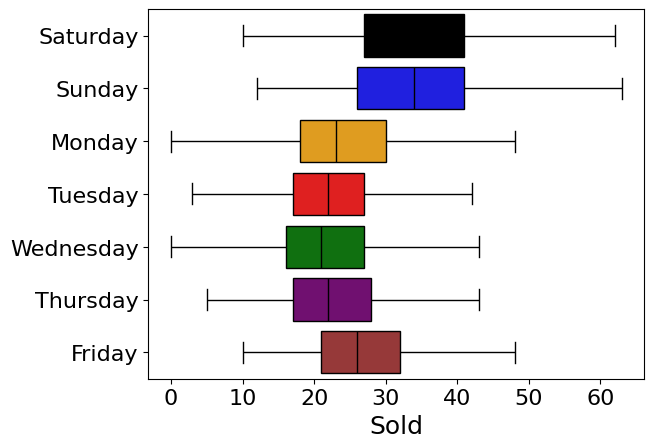

<module 'matplotlib.pyplot' from 'C:\\Users\\brend\\Desktop\\PythonVenv\\py3_13\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [22]:
from Utilities.Charting import plot_boxplot

plot_boxplot(series_df, 'sold', 'dayofweekname', custom_palette=custom_palette,
             grouping_column_label='', show_outliers=False, horizontal=True)

C:\Users\brend\Desktop\GitHub\TimeSeriesWithPyTorch\src\Utilities\Charting.py:38: UserWarning: The palette list has more values (15) than needed (12), which may not be intended.
  sns.boxplot(


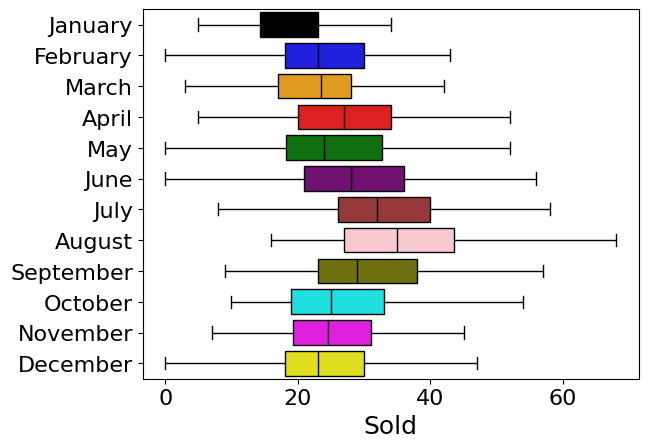

In [23]:
from Utilities.Charting import plot_boxplot
plot = plot_boxplot(series_df, 'sold', 'monthname',
                    grouping_column_label='',
                    show_outliers=False, custom_palette=custom_palette, horizontal=True)

C:\Users\brend\Desktop\GitHub\TimeSeriesWithPyTorch\src\Utilities\Charting.py:38: UserWarning: The palette list has more values (15) than needed (6), which may not be intended.
  sns.boxplot(


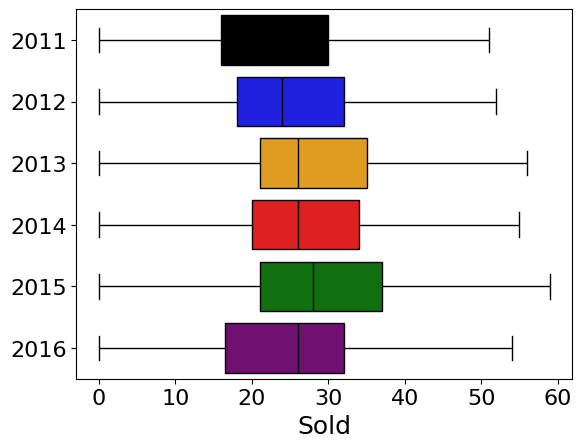

<module 'matplotlib.pyplot' from 'C:\\Users\\brend\\Desktop\\PythonVenv\\py3_13\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [24]:
plot_boxplot(series_df,'sold', 'year', value_column_label='Sold', grouping_column_label='', horizontal=True, custom_palette=custom_palette, show_outliers=False)

We see little difference across the years, which indicates a fairly stable stochastic process. Boxplots can reveal more than the seasonality composition, potentially highlighting distributions across different temporal resolutions (i.e., days, weeks, months, etc.). This can be incredibly useful when building features and deciding on algorithms for modeling. They expand our earlier analysis by providing a different perspective on seasonality, and are particularly useful for investigating multiple seasonal
patterns.

### AutoCorrelation

In [25]:
series_df['lag_1'] = series_df['sold'].shift(1) # Lag of 1 day
series_df['lag_2'] = series_df['sold'].shift(2) # Lag of 2 days
series_df['lag_3'] = series_df['sold'].shift(3) # Lag of 3 day
series_df['lag_4'] = series_df['sold'].shift(4) # Lag of 4 days
series_df['lag_5'] = series_df['sold'].shift(5) # Lag of 5 day
series_df['lag_6'] = series_df['sold'].shift(6) # Lag of 6 days
series_df['lag_7'] = series_df['sold'].shift(7) # Lag of 7 day i.e. week

print(series_df[[
 'date','sold',
 'lag_1','lag_2','lag_3', 'lag_4','lag_5','lag_6','lag_7'
]].head(n=10))

            date  sold  lag_1  lag_2  lag_3  lag_4  lag_5  lag_6  lag_7
29535 2011-01-29    18    NaN    NaN    NaN    NaN    NaN    NaN    NaN
29536 2011-01-30    17   18.0    NaN    NaN    NaN    NaN    NaN    NaN
29537 2011-01-31    10   17.0   18.0    NaN    NaN    NaN    NaN    NaN
29538 2011-02-01    15   10.0   17.0   18.0    NaN    NaN    NaN    NaN
29539 2011-02-02     7   15.0   10.0   17.0   18.0    NaN    NaN    NaN
29540 2011-02-03    13    7.0   15.0   10.0   17.0   18.0    NaN    NaN
29541 2011-02-04    24   13.0    7.0   15.0   10.0   17.0   18.0    NaN
29542 2011-02-05    30   24.0   13.0    7.0   15.0   10.0   17.0   18.0
29543 2011-02-06    30   30.0   24.0   13.0    7.0   15.0   10.0   17.0
29544 2011-02-07    23   30.0   30.0   24.0   13.0    7.0   15.0   10.0


You can see we are simply moving the column across and down by the shifted value.

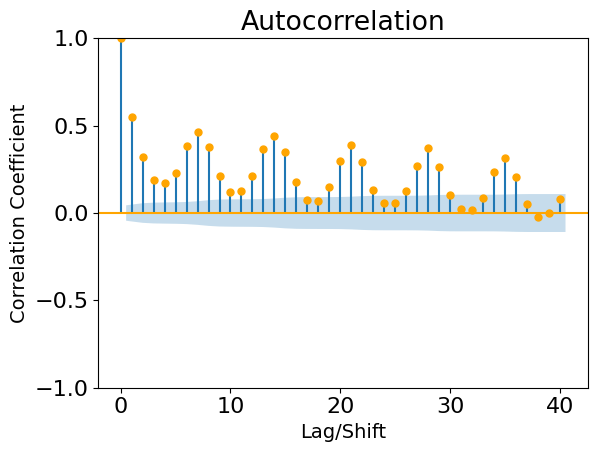

<module 'matplotlib.pyplot' from 'C:\\Users\\brend\\Desktop\\PythonVenv\\py3_13\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [26]:
from Utilities.Charting import plot_autocorrelation_factor, plot_partial_autocorrelation_factor
plot_autocorrelation_factor(series_df, 'sold', lags=40, color=custom_palette[2])

In [27]:
from statsmodels.tsa.stattools import acf, pacf

autocorrelations = acf(series_df['sold'], nlags=40, fft=True)
autocorr_df = pd.DataFrame({'Lag': range(len(autocorrelations)),'Autocorrelation': autocorrelations})
print(autocorr_df.head(10))

   Lag  Autocorrelation
0    0         1.000000
1    1         0.552307
2    2         0.320304
3    3         0.188578
4    4         0.173099
5    5         0.231156
6    6         0.382815
7    7         0.462807
8    8         0.375101
9    9         0.209550


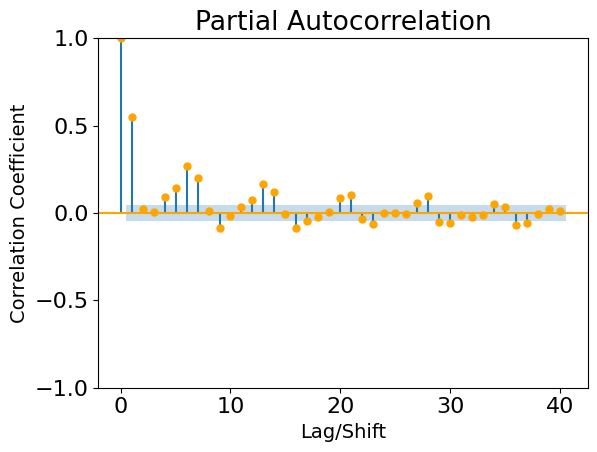

<module 'matplotlib.pyplot' from 'C:\\Users\\brend\\Desktop\\PythonVenv\\py3_13\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [28]:
plot_partial_autocorrelation_factor(series_df, 'sold', lags=40, color=custom_palette[2])

### Feature Importance/Explainability through OLS:

In [29]:
from Modeling.StatisticalModeling.OLS import ols_model_summary
# Sample data: X (independent variable), y (dependent variable)
X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 3, 5, 4, 6])

ols_model_summary(X, y)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.810
Model:                            OLS   Adj. R-squared:                  0.747
Method:                 Least Squares   F-statistic:                     12.79
Date:                Fri, 18 Sep 2026   Prob (F-statistic):             0.0374
Time:                        13:26:27   Log-Likelihood:                -4.6757
No. Observations:                   5   AIC:                             13.35
Df Residuals:                       3   BIC:                             12.57
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3000      0.835      1.558      0.2

C:\Users\brend\Desktop\PythonVenv\py3_13\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


### Stationarity

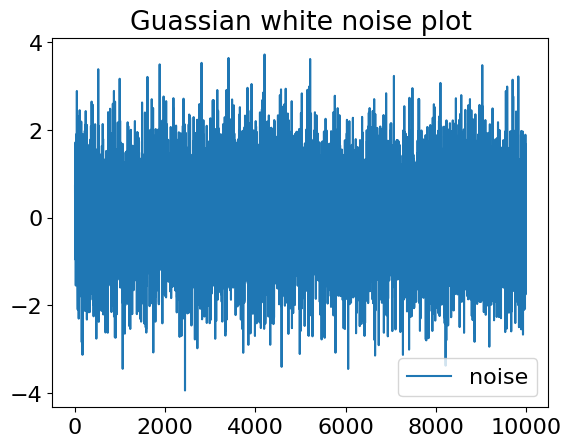

In [30]:
import pandas as pd
import numpy as np

series = pd.DataFrame(
 data = np.random.normal(0, 1, 10000),
 columns = ['noise']
)

series.plot(title='Guassian white noise plot')
print()

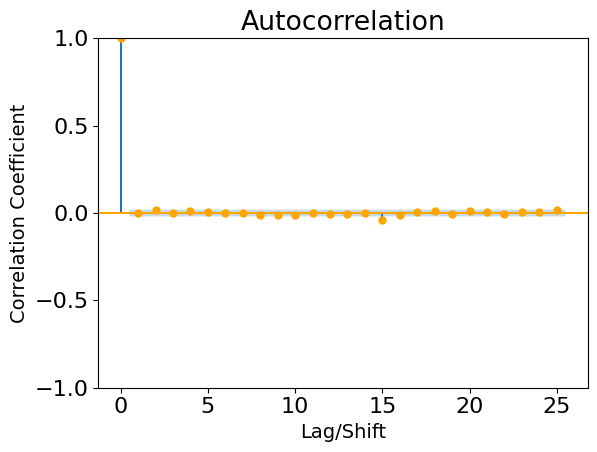

<module 'matplotlib.pyplot' from 'C:\\Users\\brend\\Desktop\\PythonVenv\\py3_13\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [31]:
plot_autocorrelation_factor(series,'noise', lags=25, color=custom_palette[2])

In [32]:
from pathlib import Path
import pandas as pd

path = Path.cwd().parent / "Data" / "passengers.csv"
series = pd.read_csv(path)
series.head(n=5)

,date,passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [33]:
X = series.passengers.values
from Modeling.StatisticalModeling.StationarityTesting import kpss_stationarity_test
kpss_stationarity_test(X)

KPSS Statistic: 1.651312
p-value: 0.010000
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739


C:\Users\brend\Desktop\GitHub\TimeSeriesWithPyTorch\src\Modeling\StatisticalModeling\StationarityTesting.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(data)


In [38]:
from statsmodels.tsa.stattools import kpss
import matplotlib.pyplot as plt
from Utilities.DataFrameUtilities import dataframe_set_index, dataframe_set_datatype_as_date

dataframe_set_datatype_as_date(series, 'date')
dataframe_set_index(series, 'date')
series

,passengers
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [35]:
from Utilities.ColorUtilities import custom_palette
def kpss_test(series):
    result = kpss(series.dropna())
    return f'KPSS Statistic: {result[0]:.3f}, p-value: {result[1]:.3f}'

def plot_transformation(original, transformed, title):
    plt.figure(figsize=(12, 6))
    plt.plot(original, color=custom_palette[0], label='Original')
    plt.plot(transformed, color=custom_palette[1], label='Transformed')
    original_kpss = kpss_test(original)
    transformed_kpss = kpss_test(transformed)
    plt.title(f'{title}\nOriginal: {original_kpss}\nTransformed: {transformed_kpss}')
    plt.legend()
    plt.tight_layout()
    plt.show()

C:\Users\brend\AppData\Local\Temp\ipykernel_101732\2199803268.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna())
C:\Users\brend\AppData\Local\Temp\ipykernel_101732\2199803268.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna())


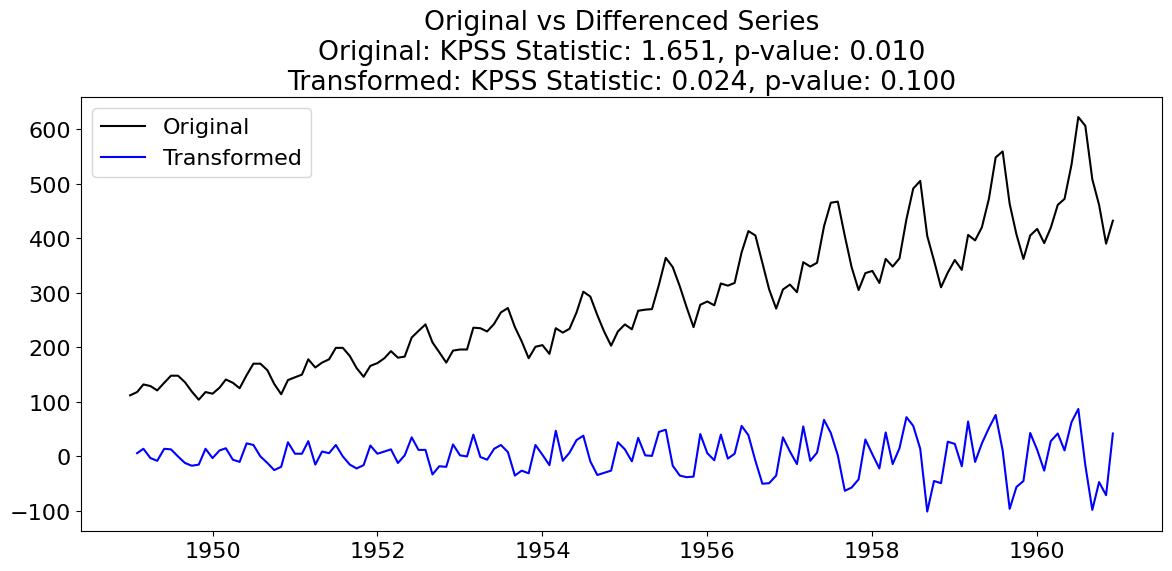

In [36]:
diff_series = series.diff().dropna()
plot_transformation(series, diff_series, 'Original vs Differenced Series')

C:\Users\brend\AppData\Local\Temp\ipykernel_101732\2199803268.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna())
C:\Users\brend\AppData\Local\Temp\ipykernel_101732\2199803268.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna())


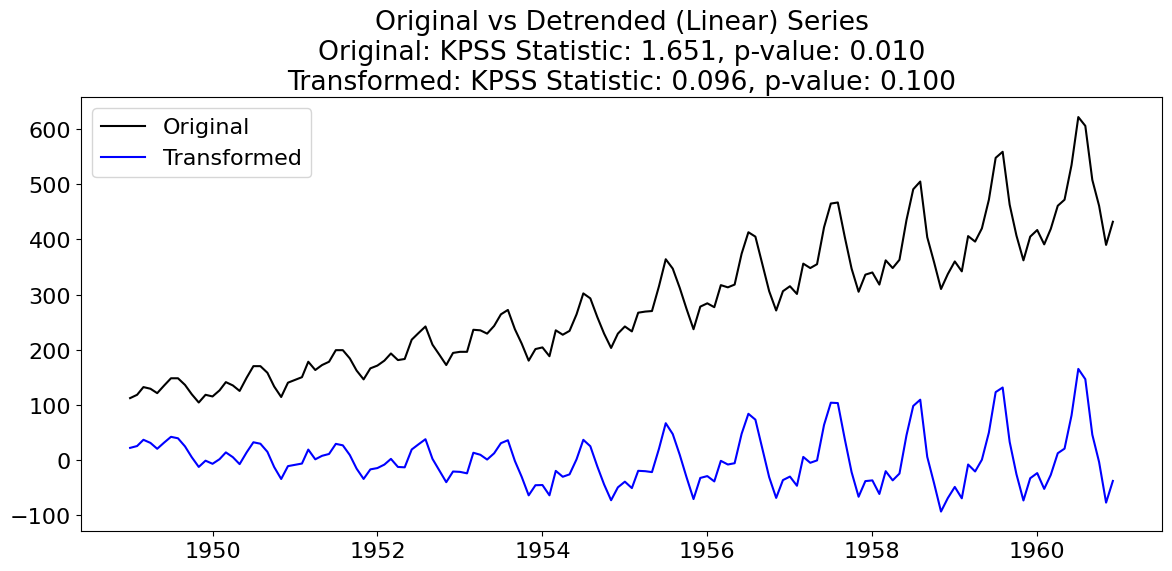

In [42]:
from scipy import stats
from scipy import signal

diff_series = bc_detrend_series = pd.Series(signal.detrend(series.values.flatten()),
index=series.index)
plot_transformation(series, diff_series, 'Original vs Detrended (Linear) Series')

C:\Users\brend\AppData\Local\Temp\ipykernel_101732\2199803268.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna())
C:\Users\brend\AppData\Local\Temp\ipykernel_101732\2199803268.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna())


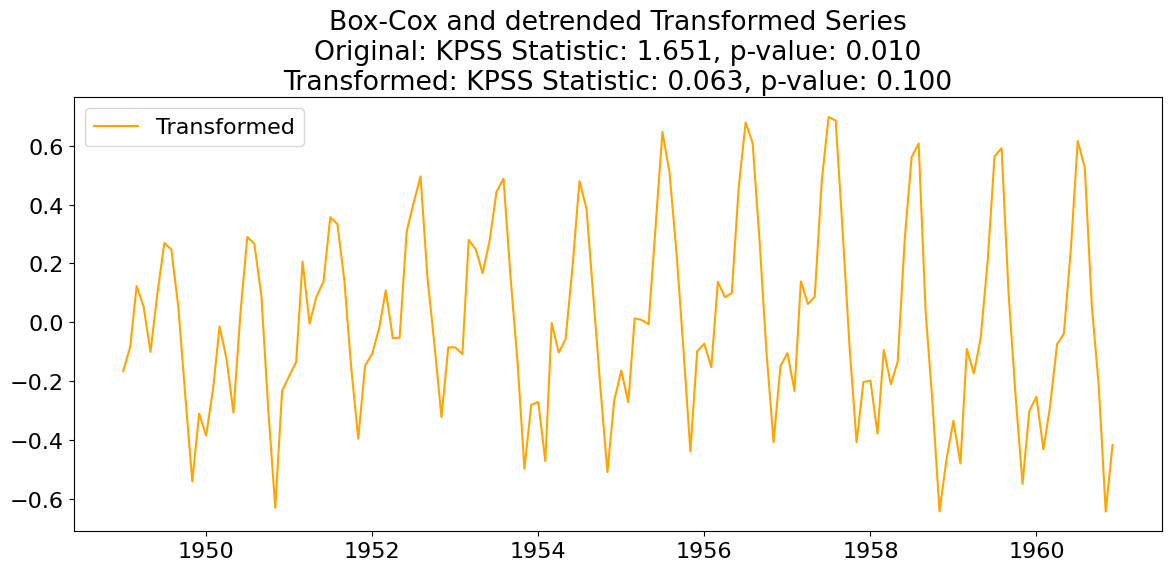

In [40]:
bc_series, lambda_param = stats.boxcox(series.values.flatten())
bc_series = pd.Series(bc_series, index=series.index)
bc_detrend_series = pd.Series(signal.detrend(bc_series.values.flatten()),
index=bc_series.index)

plt.figure(figsize=(12, 6))
plt.plot(bc_detrend_series, color=custom_palette[2], label='Transformed')
original_kpss = kpss_test(series)
transformed_kpss = kpss_test(bc_detrend_series)
plt.title(f'{'Box-Cox and detrended Transformed Series'}\nOriginal: {original_kpss}\nTransformed: {transformed_kpss}')
plt.legend()
plt.tight_layout()
plt.show()